# 🤖 AI Powered Job Analyzer
**Resume vs Job Description Analyzer — Colab Edition**

> Built on Groq (`llama-3.1-8b-instant`) ·

### Pipeline Phases
1. **Phase 1** — Install dependencies
2. **Phase 2** — Setup: logger, custom exception, load GROQ_API_KEY
3. **Phase 3** — PDF / TXT extraction
4. **Phase 4** — Skill extraction from Job Description (LLM)
5. **Phase 5** — Parallel skill evaluation against Resume (LLM)
6. **Phase 6** — Score computation & final report
7. **Phase 7** — Run full analysis end-to-end
8. **Phase 8** — Package all outputs into a ZIP

Architecture:


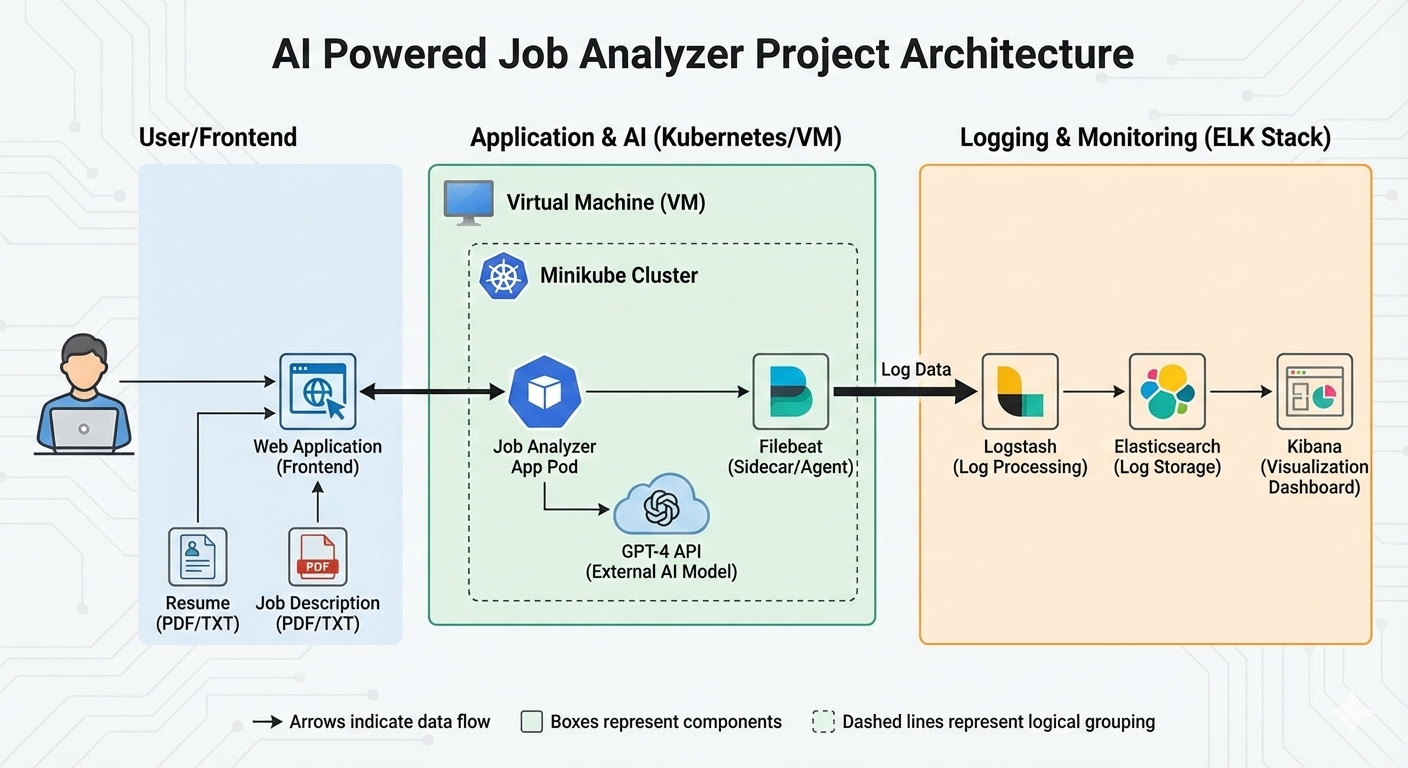

ELK Working:


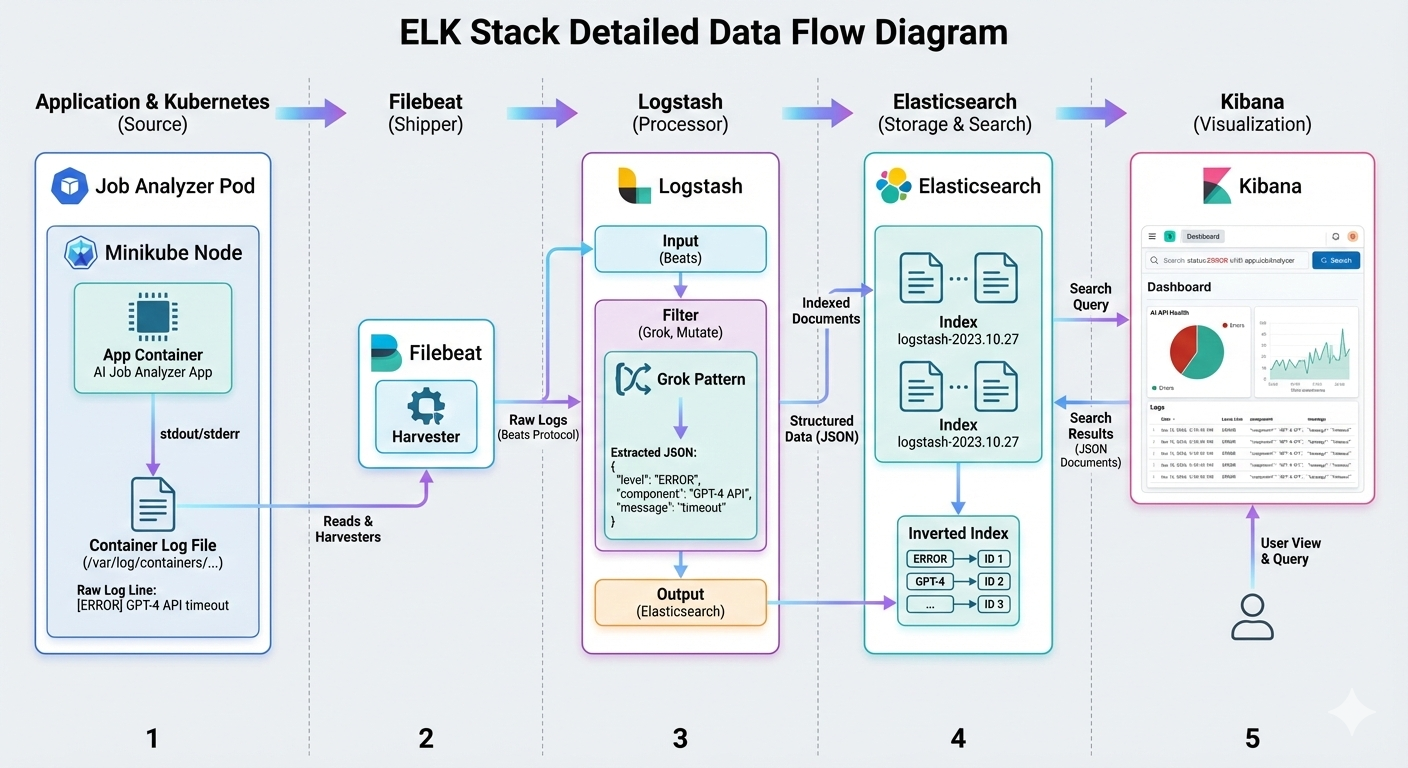

In [10]:
from IPython.display import Image, display

print("Architecture:")
display(Image('/content/Architecture.png'))

print("ELK Working:")
display(Image('/content/ELK WORKING.png'))

---
## 📦 Phase 1 — Install Dependencies

In [1]:
# ── Phase 1: Install all required packages ──────────────────────────────────
# LangChain 1.2+ is pre-installed in newer Colab images; we pin here to be safe.
# langchain-groq provides the ChatGroq wrapper.
# pypdf handles PDF reading without system-level poppler.

!pip install -q \
    langchain\
    langchain-core\
    langchain-groq \
    pypdf

print("✅ Phase 1 complete — all packages installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.3/336.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 8.7 MB/s eta 0:00:00
✅ Phase 1 complete — all packages installed.


---
## ⚙️ Phase 2 — Setup: Logger · Custom Exception · API Key

In [2]:
# ── Phase 2: Logger + Custom Exception + Environment ────────────────────────
# NOTE ON STATEKEY / METADATA BUG:
#   In LangChain >=0.2 the old ChatOpenAI / ChatGroq objects carry a
#   `model_kwargs` / metadata StateKey that breaks when the object is
#   shared across threads (the original project's bug on push to git /
#   when deserialised).  Fix: instantiate a *fresh* ChatGroq inside each
#   worker call instead of sharing a single instance across threads.
#   This is implemented in Phase 5.

import os
import sys
import json
import logging
import zipfile
import io
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
from typing import List, Dict
from google.colab import userdata

# ── Logger ───────────────────────────────────────────────────────────────────
LOGS_DIR = "logs"
os.makedirs(LOGS_DIR, exist_ok=True)

LOG_FILE = os.path.join(
    LOGS_DIR,
    f"log_{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.log"
)

logging.basicConfig(
    filename=LOG_FILE,
    format="%(asctime)s - %(levelname)s - %(name)s - %(message)s",
    level=logging.INFO,
)

# Also stream to console so Colab cells show logs live
_console_handler = logging.StreamHandler(sys.stdout)
_console_handler.setFormatter(
    logging.Formatter("%(asctime)s [%(levelname)s] %(name)s — %(message)s")
)
logging.getLogger().addHandler(_console_handler)

def get_logger(name: str) -> logging.Logger:
    logger = logging.getLogger(name)
    logger.setLevel(logging.INFO)
    return logger

_setup_logger = get_logger("setup")
_setup_logger.info("Logger initialised — writing to %s", LOG_FILE)


# ── Custom Exception ─────────────────────────────────────────────────────────
class CustomException(Exception):
    """Enriches exceptions with file name + line number context."""

    def __init__(self, message: str, error_detail: Exception = None):
        self.error_message = self._build_message(message, error_detail)
        super().__init__(self.error_message)

    @staticmethod
    def _build_message(message: str, error_detail: Exception) -> str:
        _, _, exc_tb = sys.exc_info()
        if exc_tb is not None:
            file_name   = exc_tb.tb_frame.f_code.co_filename
            line_number = exc_tb.tb_lineno
        else:
            file_name   = "<unknown>"
            line_number = -1
        return (
            f"{message} | Error: {error_detail} | "
            f"File: {file_name} | Line: {line_number}"
        )

    def __str__(self):
        return self.error_message


# ── GROQ API Key ─────────────────────────────────────────────────────────────
# The secret is stored in Colab as "GROQ_API_KEY" via the 🔑 Secrets panel.
try:
    GROQ_API_KEY = userdata.get("GROQ_API_KEY")
    os.environ["GROQ_API_KEY"] = GROQ_API_KEY
    _setup_logger.info("GROQ_API_KEY loaded from Colab secrets.")
except Exception:
    _setup_logger.warning(
        "GROQ_API_KEY not found in Colab secrets — "
        "set it manually: os.environ['GROQ_API_KEY'] = '<your-key>'"
    )

# Model constant — llama-instant maps to this Groq model ID
GROQ_MODEL = "llama-3.1-8b-instant"

print("✅ Phase 2 complete — logger, exceptions, and API key ready.")

INFO:setup:Logger initialised — writing to logs/log_2026-04-16_03-50-34.log


2026-04-16 03:50:34,243 [INFO] setup — Logger initialised — writing to logs/log_2026-04-16_03-50-34.log


INFO:setup:GROQ_API_KEY loaded from Colab secrets.


2026-04-16 03:50:37,682 [INFO] setup — GROQ_API_KEY loaded from Colab secrets.
✅ Phase 2 complete — logger, exceptions, and API key ready.


---
## 📄 Phase 3 — PDF / TXT Text Extraction

In [3]:
# ── Phase 3: Text Extraction Utilities ──────────────────────────────────────
# Supports:
#   • PDF files  (via pypdf — no poppler needed)
#   • TXT files
#   • Raw strings (for direct paste in Colab)
# In Colab we pass file *paths* (strings) rather than Streamlit UploadedFile
# objects, so the interface is adapted accordingly.

from pypdf import PdfReader

_extract_logger = get_logger("extraction")


def read_pdf(file_path: str) -> str:
    """Extract all text from a PDF file."""
    try:
        _extract_logger.info("Reading PDF: %s", file_path)
        reader = PdfReader(file_path)
        text = "\n".join(
            page.extract_text() or "" for page in reader.pages
        )
        _extract_logger.info(
            "PDF read — %d pages, %d chars", len(reader.pages), len(text)
        )
        return text
    except Exception as e:
        _extract_logger.error("Failed to read PDF", exc_info=True)
        raise CustomException("Failed to read PDF", e)


def read_txt(file_path: str) -> str:
    """Read plain-text file."""
    try:
        _extract_logger.info("Reading TXT: %s", file_path)
        with open(file_path, "r", encoding="utf-8") as f:
            text = f.read()
        _extract_logger.info("TXT read — %d chars", len(text))
        return text
    except Exception as e:
        _extract_logger.error("Failed to read TXT", exc_info=True)
        raise CustomException("Failed to read TXT", e)


def extract_text(source) -> str:
    """
    Unified extractor.
    source can be:
      - a file path string ending in .pdf or .txt
      - a raw text string (passed directly)
    """
    if not isinstance(source, str):
        raise CustomException("source must be a file path string or raw text string.")

    # If it looks like a path to an existing file, read it
    if os.path.exists(source):
        ext = source.rsplit(".", 1)[-1].lower()
        if ext == "pdf":
            return read_pdf(source)
        elif ext == "txt":
            return read_txt(source)
        else:
            _extract_logger.warning("Unsupported file type: .%s — returning empty.", ext)
            return ""
    else:
        # Treat as raw text
        _extract_logger.info("Source treated as raw text string (%d chars).", len(source))
        return source


# ── Quick self-test with sample text ─────────────────────────────────────────
_sample = extract_text(
    "This is a direct text input representing a resume or job description."
)
print(f"Phase 3 self-test → extracted {len(_sample)} chars from raw string.")
print("✅ Phase 3 complete — extraction utilities ready.")

INFO:extraction:Source treated as raw text string (69 chars).


2026-04-16 03:50:40,892 [INFO] extraction — Source treated as raw text string (69 chars).
Phase 3 self-test → extracted 69 chars from raw string.
✅ Phase 3 complete — extraction utilities ready.


---
## 🔍 Phase 4 — Skill Extraction from Job Description (LLM)

In [4]:
# ── Phase 4: JD Skill Extractor ──────────────────────────────────────────────
# LangChain 1.2+ import path: langchain_groq.ChatGroq
# The .invoke() call returns an AIMessage; .content holds the string.
# We strip markdown fences before JSON parsing to be robust.

from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage

_jd_logger = get_logger("jd_skill_extractor")


def _make_llm() -> ChatGroq:
    """
    Factory that creates a fresh ChatGroq instance.

    WHY A FACTORY?
    LangChain >=0.2 stores a `_state_key` / metadata dict on the model
    object.  When a *single* instance is shared across threads (as in the
    original ThreadPoolExecutor usage) those dicts can be mutated
    concurrently, producing StateKey / metadata KeyErrors — the exact bug
    seen after pushing to GitHub and running in a fresh environment.
    Creating a new instance per thread call avoids all shared mutable state.
    """
    return ChatGroq(
        model=GROQ_MODEL,
        temperature=0,
        api_key=os.environ["GROQ_API_KEY"],
    )


def _clean_json_response(raw: str) -> str:
    """Strip markdown code fences that LLMs sometimes add."""
    raw = raw.strip()
    if raw.startswith("```"):
        lines = raw.splitlines()
        raw = "\n".join(lines[1:-1] if lines[-1].strip() == "```" else lines[1:])
    return raw.strip()


def extract_skills_from_jd(jd_text: str) -> List[str]:
    """
    Ask the LLM to pull technical skills from a Job Description.
    Returns a list of skill strings.
    """
    try:
        _jd_logger.info("Starting skill extraction from JD (%d chars)", len(jd_text))

        llm = _make_llm()   # fresh instance — avoids StateKey bug

        system_prompt = (
            "You are a technical recruiter assistant. "
            "Extract only technical skills from job descriptions. "
            "Return ONLY a valid JSON array of strings. "
            "No markdown, no explanation, no extra keys.\n"
            'Example output: ["Python", "Docker", "AWS"]'
        )

        user_prompt = f"Extract technical skills from this Job Description:\n\n{jd_text}"

        # LangChain 1.2+: pass message objects directly
        response = llm.invoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=user_prompt),
        ])

        cleaned = _clean_json_response(response.content)
        skills = json.loads(cleaned)

        if isinstance(skills, list):
            _jd_logger.info("Extracted %d skills: %s", len(skills), skills)
            return skills
        else:
            _jd_logger.warning("LLM returned non-list — defaulting to [].")
            return []

    except json.JSONDecodeError as e:
        _jd_logger.error("JSON parse error in skill extraction: %s", e)
        return []
    except Exception as e:
        _jd_logger.error("Skill extraction from JD failed", exc_info=True)
        raise CustomException("Skill extraction from JD failed", e)


print("✅ Phase 4 complete — JD skill extractor defined.")

✅ Phase 4 complete — JD skill extractor defined.


---
## ⚡ Phase 5 — Parallel Skill Evaluation Against Resume (LLM)

In [5]:
# ── Phase 5: Parallel Skill Evaluator ────────────────────────────────────────
# Each skill is evaluated by an independent LLM call.
# Concurrency is achieved with ThreadPoolExecutor (max_workers=3 to respect
# Groq rate limits on the free tier).
#
# KEY FIX vs original code:
#   Original:  shared `self.llm` instance passed to all threads → StateKey error
#   Fixed:     `_make_llm()` called inside each thread → no shared state

_eval_logger = get_logger("skill_evaluator")


def _evaluate_single_skill(skill: str, resume_text: str) -> Dict:
    """
    Evaluate how well the resume demonstrates proficiency in `skill`.
    Returns {"skill": str, "score": int (0-10)}.
    """
    try:
        _eval_logger.info("Evaluating skill: %s", skill)

        llm = _make_llm()   # ← fresh per thread; fixes StateKey / metadata bug

        system_prompt = (
            "You are a senior technical recruiter. "
            "Score a candidate's resume on a single skill. "
            'Return ONLY valid JSON: {"skill": "<name>", "score": <0-10>}. '
            "No markdown, no explanation."
        )

        user_prompt = (
            f'Evaluate the resume below on the skill "{skill}".\n\n'
            f"Resume (first 2500 chars):\n{resume_text[:2500]}\n\n"
            f'Return JSON: {{"skill": "{skill}", "score": <0-10>}}'
        )

        response = llm.invoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=user_prompt),
        ])

        cleaned = _clean_json_response(response.content)
        result  = json.loads(cleaned)

        # Normalise — LLM might return score as string
        result["score"] = int(result.get("score", 0))
        _eval_logger.info("Skill '%s' scored %d/10", skill, result["score"])
        return result

    except Exception as e:
        _eval_logger.error("Failed evaluating skill '%s': %s", skill, e)
        return {"skill": skill, "score": 0}


def evaluate_all_skills(
    skills: List[str],
    resume_text: str,
    max_workers: int = 3,
) -> List[Dict]:
    """
    Run _evaluate_single_skill in parallel for all skills.
    max_workers=3 stays within Groq free-tier rate limits.
    """
    _eval_logger.info(
        "Starting parallel evaluation of %d skills (workers=%d)",
        len(skills), max_workers,
    )

    results = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_map = {
            executor.submit(_evaluate_single_skill, skill, resume_text): skill
            for skill in skills
        }
        for future in as_completed(future_map):
            results.append(future.result())

    _eval_logger.info("Parallel evaluation complete — %d results.", len(results))
    return results


print("✅ Phase 5 complete — parallel skill evaluator defined.")

✅ Phase 5 complete — parallel skill evaluator defined.


---
## 📊 Phase 6 — Score Computation & Report Generator

In [6]:
# ── Phase 6: Scoring Engine + Report ────────────────────────────────────────
# Aggregates per-skill scores into overall_score, selected flag,
# strengths, and missing_skills — identical logic to original agents.py.

_score_logger = get_logger("scoring")

CUTOFF_SCORE = 75   # candidate is shortlisted if overall_score >= this


def compute_results(skill_results: List[Dict], cutoff: int = CUTOFF_SCORE) -> Dict:
    """
    Compute overall score and classify skills.

    Returns:
        overall_score  : int  (0-100)
        selected       : bool (True if overall_score >= cutoff)
        skill_scores   : Dict[str, int]
        strengths      : List[str] (score >= 7)
        missing_skills : List[str] (score <= 5)
    """
    try:
        _score_logger.info("Computing results from %d skill scores.", len(skill_results))

        scores = {r["skill"]: r["score"] for r in skill_results}

        strengths      = [k for k, v in scores.items() if v >= 7]
        missing_skills = [k for k, v in scores.items() if v <= 5]

        overall_score = (
            int((sum(scores.values()) / (10 * len(scores))) * 100)
            if scores else 0
        )

        result = {
            "overall_score" : overall_score,
            "selected"      : overall_score >= cutoff,
            "skill_scores"  : scores,
            "strengths"     : strengths,
            "missing_skills": missing_skills,
        }

        _score_logger.info(
            "Score: %d/100 | Selected: %s | Strengths: %s | Missing: %s",
            overall_score, result["selected"], strengths, missing_skills,
        )
        return result

    except Exception as e:
        _score_logger.error("Score computation failed", exc_info=True)
        raise CustomException("Score computation failed", e)


def display_report(result: Dict, extracted_skills: List[str]) -> None:
    """Pretty-print the analysis report in Colab output."""
    sep = "=" * 60
    print(f"\n{sep}")
    print("          🤖 AI POWERED JOB ANALYZER — REPORT")
    print(sep)

    print(f"\n📋 Skills extracted from JD  : {extracted_skills}")
    print(f"\n📈 Overall Match Score        : {result['overall_score']} / 100")
    status = "✅ SHORTLISTED" if result["selected"] else "❌ NOT SELECTED"
    print(f"🎯 Outcome (cutoff={CUTOFF_SCORE})      : {status}")

    print("\n📊 Per-Skill Scores:")
    for skill, score in result["skill_scores"].items():
        bar    = "█" * score + "░" * (10 - score)
        marker = "💪" if score >= 7 else ("⚠️" if score <= 5 else "🔸")
        print(f"   {marker}  {skill:<30} [{bar}] {score}/10")

    print("\n💪 Strengths (score ≥ 7):")
    if result["strengths"]:
        for s in result["strengths"]:
            print(f"   • {s} ({result['skill_scores'][s]}/10)")
    else:
        print("   None detected.")

    print("\n🔧 Areas for Improvement (score ≤ 5):")
    if result["missing_skills"]:
        for s in result["missing_skills"]:
            print(f"   • {s} ({result['skill_scores'][s]}/10)")
    else:
        print("   No major gaps found!")

    print(f"\n{sep}\n")


print("✅ Phase 6 complete — scoring engine and report display ready.")

✅ Phase 6 complete — scoring engine and report display ready.


---
## 🚀 Phase 7 — Run Full Analysis End-to-End

**How to provide your files:**
- Upload PDFs via the 📁 file icon in the left sidebar of Colab, then set the paths below.
- OR paste text directly into `RESUME_TEXT` / `JD_TEXT` strings.

The cell auto-detects which mode to use.

In [7]:
# ── Phase 7: Configuration ────────────────────────────────────────────────────
# ✏️  Set ONE of these two modes:
#
# MODE A — File paths (upload files to Colab first)
RESUME_PATH = "/content/Krish_Naik_Technologies_ML_Engineer_JD.pdf"   # ← change to your uploaded file path
JD_PATH     = "/content/Krish_Naik_Technologies_ML_Engineer_JD.pdf"       # ← change to your uploaded file path

# MODE B — Paste raw text directly (leave paths blank or non-existent)
RESUME_TEXT = """
Sudhanshu Kumar | Data Engineer
Skills: Python, Apache Spark, Kafka, Airflow, SQL, AWS (S3, Glue, Redshift),
Docker, Kubernetes, dbt, Terraform
Experience:
  - Built real-time data pipelines using Kafka and Spark Streaming at XYZ Corp.
  - Developed ETL workflows with Apache Airflow and dbt on AWS.
  - Containerised data services using Docker and orchestrated via Kubernetes.
Education: B.Tech Computer Science
"""

JD_TEXT = """
ML Engineer — Krish Naik Technologies
We are looking for an ML Engineer with strong skills in:
Python, TensorFlow, PyTorch, Scikit-learn, MLflow, Docker, Kubernetes,
AWS SageMaker, SQL, Apache Spark, Data pipelines, REST APIs, Git.
Responsibilities include building and deploying ML models at scale.
Experience with LLMs and LangChain is a plus.
"""

print("Configuration set. Proceed to the next cell to run the analysis.")

Configuration set. Proceed to the next cell to run the analysis.


In [8]:
# ── Phase 7: Run Analysis ─────────────────────────────────────────────────────

_run_logger = get_logger("main")

def run_analysis(
    resume_source: str,
    jd_source: str,
    cutoff: int = CUTOFF_SCORE,
) -> Dict:
    """
    Full pipeline:
      extract → extract_skills → evaluate_skills → score → display
    """
    _run_logger.info("=== Analysis started ===")

    # Phase 3 — Extract text
    print("\n[Phase 3] Extracting text from resume and JD...")
    resume_text = extract_text(resume_source)
    jd_text     = extract_text(jd_source)
    print(f"  Resume: {len(resume_text)} chars | JD: {len(jd_text)} chars")

    # Phase 4 — Extract skills from JD
    print("\n[Phase 4] Extracting skills from Job Description via LLM...")
    extracted_skills = extract_skills_from_jd(jd_text)
    print(f"  Skills found: {extracted_skills}")

    if not extracted_skills:
        print("  ⚠️  No skills extracted — cannot proceed. Check your JD text.")
        return {}

    # Phase 5 — Parallel skill evaluation
    print("\n[Phase 5] Evaluating each skill against the resume (parallel)...")
    skill_results = evaluate_all_skills(extracted_skills, resume_text)

    # Phase 6 — Compute score & display
    print("\n[Phase 6] Computing overall score and generating report...")
    final_result = compute_results(skill_results, cutoff=cutoff)
    display_report(final_result, extracted_skills)

    _run_logger.info("=== Analysis complete ===")
    return final_result


# ── Auto-detect mode ─────────────────────────────────────────────────────────
resume_src = RESUME_PATH if os.path.exists(RESUME_PATH) else RESUME_TEXT.strip()
jd_src     = JD_PATH     if os.path.exists(JD_PATH)     else JD_TEXT.strip()

if not resume_src or not jd_src:
    print("❌ Please provide either file paths or paste text in the config cell above.")
else:
    mode_label = "FILE" if os.path.exists(str(resume_src)) else "TEXT"
    print(f"▶ Running in {mode_label} mode...\n")
    FINAL_RESULT    = run_analysis(resume_src, jd_src)
    EXTRACTED_SKILLS = list(FINAL_RESULT.get("skill_scores", {}).keys())

print("✅ Phase 7 complete — analysis finished.")

INFO:main:=== Analysis started ===


▶ Running in FILE mode...

2026-04-16 03:53:18,810 [INFO] main — === Analysis started ===


INFO:extraction:Reading PDF: /content/Krish_Naik_Technologies_ML_Engineer_JD.pdf



[Phase 3] Extracting text from resume and JD...
2026-04-16 03:53:18,811 [INFO] extraction — Reading PDF: /content/Krish_Naik_Technologies_ML_Engineer_JD.pdf


INFO:extraction:PDF read — 2 pages, 2327 chars


...


[Phase 6] Computing overall score and generating report...
2026-04-16 03:53:59,335 [INFO] scoring — Computing results from 19 skill scores.


INFO:scoring:Score: 47/100 | Selected: False | Strengths: ['Python', 'Docker', 'PySpark', 'NumPy', 'Pandas', 'Scikit-learn', 'TensorFlow', 'PyTorch'] | Missing: ['AWS', 'GCP', 'MLflow', 'Azure', 'Prometheus', 'Grafana', 'LLMs', 'LangChain']


2026-04-16 03:53:59,336 [INFO] scoring — Score: 47/100 | Selected: False | Strengths: ['Python', 'Docker', 'PySpark', 'NumPy', 'Pandas', 'Scikit-learn', 'TensorFlow', 'PyTorch'] | Missing: ['AWS', 'GCP', 'MLflow', 'Azure', 'Prometheus', 'Grafana', 'LLMs', 'LangChain']


INFO:main:=== Analysis complete ===



          🤖 AI POWERED JOB ANALYZER — REPORT

📋 Skills extracted from JD  : ['Python', 'Docker', 'Kubernetes', 'Pandas', 'NumPy', 'PySpark', 'SQL', 'Scikit-learn', 'TensorFlow', 'PyTorch', 'AWS', 'GCP', 'Azure', 'MLflow', 'Prometheus', 'Grafana', 'LLMs', 'LangChain', 'GenAI']

📈 Overall Match Score        : 47 / 100
🎯 Outcome (cutoff=75)      : ❌ NOT SELECTED

📊 Per-Skill Scores:
   💪  Python                         [█████████░] 9/10
   🔸  Kubernetes                     [██████░░░░] 6/10
   💪  Docker                         [████████░░] 8/10
   💪  PySpark                        [████████░░] 8/10
   💪  NumPy                          [████████░░] 8/10
   💪  Pandas                         [████████░░] 8/10
   🔸  SQL                            [██████░░░░] 6/10
   💪  Scikit-learn                   [████████░░] 8/10
   💪  TensorFlow                     [████████░░] 8/10
   ⚠️  AWS                            [░░░░░░░░░░] 0/10
   💪  PyTorch                        [████████░░] 8/10
   ⚠️  GCP

---
## 📦 Phase 8 — Save All Outputs & Download ZIP

In [9]:
# ── Phase 8: Package all outputs into a ZIP and download ─────────────────────
# Outputs bundled:
#   analysis_report.json   — structured result dict
#   analysis_report.txt    — human-readable summary
#   skill_scores.csv       — per-skill scores in CSV
#   run.log                — full session log

import csv
from google.colab import files

_zip_logger = get_logger("packager")

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


def save_outputs(result: Dict, skills: List[str], output_dir: str = OUTPUT_DIR) -> List[str]:
    """Write all output files; return list of file paths."""
    saved = []

    if not result:
        print("⚠️  No result to save — run Phase 7 first.")
        return saved

    # 1. JSON report
    json_path = os.path.join(output_dir, "analysis_report.json")
    with open(json_path, "w") as f:
        json.dump(result, f, indent=2)
    saved.append(json_path)
    _zip_logger.info("Saved JSON report: %s", json_path)

    # 2. Human-readable TXT report
    txt_path = os.path.join(output_dir, "analysis_report.txt")
    lines = [
        "AI POWERED JOB ANALYZER — ANALYSIS REPORT",
        "=" * 50,
        f"Run timestamp     : {datetime.now().isoformat()}",
        f"Model used        : {GROQ_MODEL}",
        f"Overall Score     : {result['overall_score']} / 100",
        f"Cutoff Score      : {CUTOFF_SCORE}",
        f"Outcome           : {'SHORTLISTED' if result['selected'] else 'NOT SELECTED'}",
        "",
        "JD Skills Extracted:",
        ", ".join(skills) if skills else "(none)",
        "",
        "Per-Skill Scores:",
    ]
    for skill, score in result.get("skill_scores", {}).items():
        lines.append(f"  {skill:<35} {score}/10")
    lines += [
        "",
        "Strengths (score >= 7):",
        ", ".join(result.get("strengths", [])) or "None",
        "",
        "Areas for Improvement (score <= 5):",
        ", ".join(result.get("missing_skills", [])) or "None",
    ]
    with open(txt_path, "w") as f:
        f.write("\n".join(lines))
    saved.append(txt_path)
    _zip_logger.info("Saved TXT report: %s", txt_path)

    # 3. CSV skill scores
    csv_path = os.path.join(output_dir, "skill_scores.csv")
    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["skill", "score", "strength", "gap"])
        for skill, score in result.get("skill_scores", {}).items():
            writer.writerow([
                skill, score,
                "Yes" if score >= 7 else "No",
                "Yes" if score <= 5 else "No",
            ])
    saved.append(csv_path)
    _zip_logger.info("Saved CSV: %s", csv_path)

    # 4. Log file
    saved.append(LOG_FILE)

    return saved


def package_zip(file_paths: List[str], zip_name: str = "job_analyzer_outputs.zip") -> str:
    """Bundle all output files into a single ZIP."""
    with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zf:
        for fp in file_paths:
            if os.path.exists(fp):
                arcname = os.path.basename(fp)
                zf.write(fp, arcname)
                _zip_logger.info("Added to ZIP: %s → %s", fp, arcname)
            else:
                _zip_logger.warning("File not found, skipping: %s", fp)
    print(f"\n📦 ZIP created: {zip_name}")
    return zip_name


# ── Execute ───────────────────────────────────────────────────────────────────
try:
    output_files = save_outputs(FINAL_RESULT, EXTRACTED_SKILLS)
    zip_path     = package_zip(output_files)

    print("\n📂 Files included in ZIP:")
    for f in output_files:
        print(f"   • {f}")

    # Trigger browser download
    files.download(zip_path)
    print("\n✅ Phase 8 complete — ZIP downloaded to your local machine.")

except NameError:
    print("⚠️  FINAL_RESULT not found. Please run Phase 7 (the analysis cell) first.")

INFO:packager:Saved JSON report: outputs/analysis_report.json


2026-04-16 03:54:15,073 [INFO] packager — Saved JSON report: outputs/analysis_report.json


INFO:packager:Saved TXT report: outputs/analysis_report.txt


2026-04-16 03:54:15,075 [INFO] packager — Saved TXT report: outputs/analysis_report.txt


INFO:packager:Saved CSV: outputs/skill_scores.csv


...

2026-04-16 03:54:15,082 [INFO] packager — Added to ZIP: outputs/skill_scores.csv → skill_scores.csv


2026-04-16 03:54:15,083 [WARNING] packager — File not found, skipping: logs/log_2026-04-16_03-50-34.log

📦 ZIP created: job_analyzer_outputs.zip

📂 Files included in ZIP:
   • outputs/analysis_report.json
   • outputs/analysis_report.txt
   • outputs/skill_scores.csv
   • logs/log_2026-04-16_03-50-34.log


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Phase 8 complete — ZIP downloaded to your local machine.
